# Data to Decision: EOQ Logistics Optimization (Walmart Case)
**Author:** Miguel A. Martinez | Business Intelligence Analyst

## 1. Business Context & Data Lineage
This analytical project structures an inventory policy for a high-turnover product (`HOBBIES_1_004`) at Walmart's `CA_1` retail store. 

**Data Lineage:** The empirical data utilized in this analysis was extracted from the *M5 Forecasting - Accuracy* dataset on Kaggle, containing real transactional records from Walmart.

The executive objective is to determine the Economic Order Quantity (EOQ) that minimizes operational costs, evaluating supplier volume discount tiers, and ensuring the service level through a probabilistic safety stock model.

In [1]:
import numpy as np
import pandas as pd

print("1. Extracting transactional data from Walmart (M5 Dataset)...")
# Loading databases
df_sales = pd.read_csv('/kaggle/input/competitions/m5-forecasting-accuracy/sales_train_validation.csv')
df_prices = pd.read_csv('/kaggle/input/competitions/m5-forecasting-accuracy/sell_prices.csv')

target_sku = 'HOBBIES_1_004'
target_store = 'CA_1'

# Demand Extraction (Last 365 days)
sku_data = df_sales[(df_sales['item_id'] == target_sku) & (df_sales['store_id'] == target_store)]
days_cols = [f'd_{i}' for i in range(1913-365+1, 1914)]
annual_sales = sku_data[days_cols].values.flatten()

annual_demand = np.sum(annual_sales)
average_daily_demand = np.mean(annual_sales)
daily_std_dev = np.std(annual_sales)

# Real Unit Price Extraction
sku_prices = df_prices[(df_prices['item_id'] == target_sku) & (df_prices['store_id'] == target_store)]
real_unit_price = round(sku_prices['sell_price'].mean(), 2)

print(f" -> Annual Demand (D): {annual_demand} units")
print(f" -> Base Unit Price (C): ${real_unit_price} USD")

1. Extracting transactional data from Walmart (M5 Dataset)...
 -> Annual Demand (D): 717 units
 -> Base Unit Price (C): $4.53 USD


## 2. Logistics Parameters & Financial Modeling

For the formulation of the model, the following standard operational assumptions in the retail industry are established:
* **Working days per year:** 365 days.
* **Supplier Lead Time (L):** 7 days.
* **Ordering Cost (S):** $50.00 USD (Includes administrative and transport expenses).
* **Holding Rate (i):** 20% annually (Opportunity cost and warehousing).

**Cost Differentiation:**
It is critical for financial administration to separate two categories:
1. **Operational Total Cost (TC):** Exclusively the sum of the annual ordering cost plus the annual holding cost.
2. **Total Inventory Cost (TIC):** Integrates the operational TC plus the capital tied up in purchasing the merchandise (Annual Demand $\times$ Unit Cost).

In [2]:
print("2. Executing EOQ Optimization Engine with Discounts...\n")

working_days = 365
lead_time = 7
ordering_cost = 50.00
holding_rate = 0.20

# Discount Tiers: (Min_Qty, Max_Qty, Price)
discount_tiers = [
    (0, 99, real_unit_price), 
    (100, 199, round(real_unit_price * 0.94, 2)), # 6% discount
    (200, float('inf'), round(real_unit_price * 0.88, 2)) # 12% discount
]

results = []

for min_q, max_q, price in discount_tiers:
    holding_cost = price * holding_rate
    
    # Basic EOQ Calculation
    eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)
    
    # Range Constraints
    if eoq < min_q: optimal_qty = min_q
    elif eoq > max_q: optimal_qty = max_q
    else: optimal_qty = eoq
        
    # --- BUSINESS CORRECTION: Round to discrete integer units ---
    optimal_qty = int(round(optimal_qty))
        
    # Financial Calculations (now based on real discrete units)
    material_cost = annual_demand * price
    annual_ordering_cost = (annual_demand / optimal_qty) * ordering_cost
    annual_holding_cost = (optimal_qty / 2) * holding_cost
    
    operational_tc = annual_ordering_cost + annual_holding_cost
    global_tic = operational_tc + material_cost
    
    # Operational Metrics
    orders_per_year = annual_demand / optimal_qty
    days_between_orders = int(round(working_days / orders_per_year))
    
    results.append({
        'Unit_Price_USD': price,
        'Order_Qty': optimal_qty,
        'Orders/Year': round(orders_per_year, 1), # Kept as decimal rate for financial accuracy
        'Days_Frequency': days_between_orders,
        'Operational_TC': round(operational_tc, 2),
        'Global_TIC': round(global_tic, 2)
    })

df_results = pd.DataFrame(results)
best_option = df_results.loc[df_results['Global_TIC'].idxmin()]

print("--- SCENARIO EVALUATION ---")
print(df_results.to_string(index=False))

2. Executing EOQ Optimization Engine with Discounts...

--- SCENARIO EVALUATION ---
 Unit_Price_USD  Order_Qty  Orders/Year  Days_Frequency  Operational_TC  Global_TIC
           4.53         99          7.2              50          406.97     3654.98
           4.26        199          3.6             101          264.92     3319.34
           3.99        300          2.4             153          239.20     3100.03


## 3. Scenario Analysis & Procurement Decision

The evaluation table presents three scenarios based on the supplier's volume discount structure. To ensure the mathematical model is viable in real-world inventory administration, a strict parameterization was applied, distinguishing between physical operational reality and financial metrics.

**Technical Note on Data Modeling:**
* **Operational Execution (Discrete Values):** The order quantities (`Order_Qty`) and frequency in days (`Days_Frequency`) have been strictly adjusted to integers. Logistically, it is impossible to issue purchase orders for fractional units or schedule warehouse deliveries for half a day.
* **Financial Projection (Continuous Rate):** The `Orders/Year` metric retains its decimal format (e.g., 2.4). This is because it does not represent an isolated physical event, but rather an annualized financial rate. Rounding this multiplier would distort the calculation of the Annual Ordering Cost, impacting the economic accuracy of the model.

**Scenario Interpretation:**
* **Scenario 1 (No discount):** Ordering 99 units yields the highest operational cost and fails to leverage any commercial benefits.
* **Scenario 2 (6% discount):** Increasing the batch to 199 units significantly reduces the acquisition cost but still does not optimize warehouse retention.
* **Scenario 3 (12% discount - Optimal Decision):** By issuing orders for **300 discrete units** every **153 days**, the operation reaches its maximum efficiency point. Although holding more inventory slightly increases storage expenses, the 12% commercial discount on the material cost completely absorbs this impact, minimizing the Total Inventory Cost (Global TIC) to **$3,100.03 USD**.

## 4. Risk Mitigation & Cost Curve

Isolating an optimal quantity is only the first step. Since real demand fluctuates daily, operating under a purely deterministic model generates a high risk of stockouts. 

Below, the **Safety Stock** is calculated using the standard deviation of historical demand to guarantee a 95% service level. Finally, the cost curve is plotted to visualize the impact of the decision on the company's cash flow.

--- RISK MITIGATION INDICATORS ---
Required Safety Stock (95% Service Level): 9.36 units
Probabilistic Reorder Point (ROP): 23.11 units



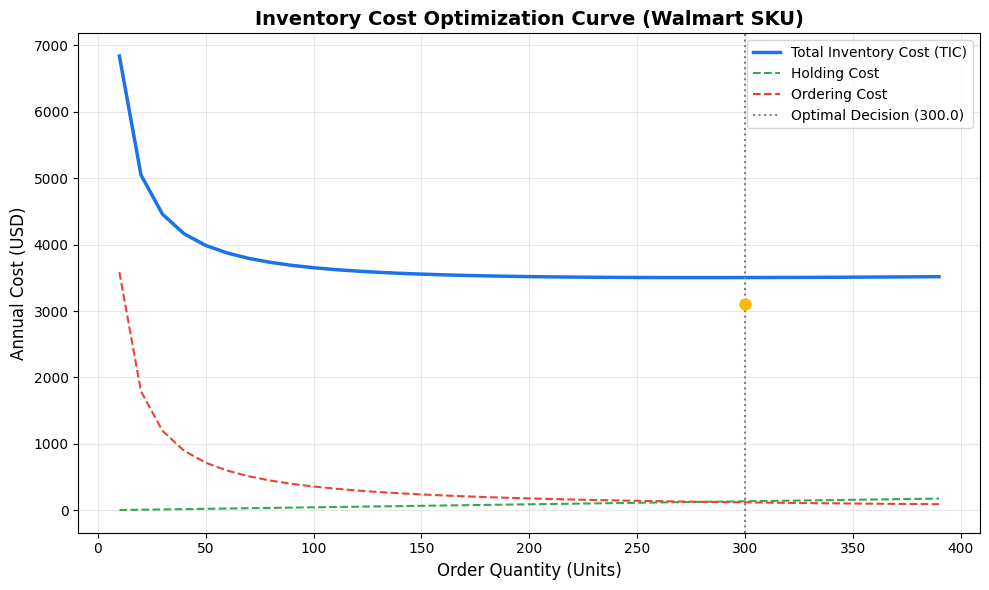

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. PROBABILISTIC MODEL ---
service_level = 0.95
z_score = norm.ppf(service_level)

safety_stock = z_score * daily_std_dev * np.sqrt(lead_time)
probabilistic_rop = (average_daily_demand * lead_time) + safety_stock

print("--- RISK MITIGATION INDICATORS ---")
print(f"Required Safety Stock (95% Service Level): {round(safety_stock, 2)} units")
print(f"Probabilistic Reorder Point (ROP): {round(probabilistic_rop, 2)} units\n")

# --- 2. COST CURVE VISUALIZATION ---
quantities = np.arange(10, 400, 10)
holding_costs_list = []
ordering_costs_list = []
tic_list = []

base_holding_cost = real_unit_price * holding_rate

for q in quantities:
    c_holding = (q / 2) * base_holding_cost
    c_ordering = (annual_demand / q) * ordering_cost
    c_total = c_holding + c_ordering + (annual_demand * real_unit_price)
    
    holding_costs_list.append(c_holding)
    ordering_costs_list.append(c_ordering)
    tic_list.append(c_total)

plt.figure(figsize=(10, 6))
plt.plot(quantities, tic_list, label='Total Inventory Cost (TIC)', color='#1A73E8', linewidth=2.5)
plt.plot(quantities, holding_costs_list, label='Holding Cost', color='#34A853', linestyle='--')
plt.plot(quantities, ordering_costs_list, label='Ordering Cost', color='#EA4335', linestyle='--')

plt.axvline(x=best_option['Order_Qty'], color='gray', linestyle=':', label=f"Optimal Decision ({best_option['Order_Qty']})")
plt.plot(best_option['Order_Qty'], best_option['Global_TIC'], marker='o', markersize=8, color='#FBBC05')

plt.title('Inventory Cost Optimization Curve (Walmart SKU)', fontsize=14, fontweight='bold')
plt.xlabel('Order Quantity (Units)', fontsize=12)
plt.ylabel('Annual Cost (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Executive Conclusion & Logistics Interpretation

Based on the evaluation of the cost curve and risk indicators, the following operational guidelines are established:

**What decision should the company make with these results?** The company must immediately abandon the purchase of small batches. The optimal decision is to issue purchase orders for **300 units** (leveraging the maximum 12% discount) with an approximate frequency of **153 days**. Although the Operational Cost (TC) rises due to warehouse retention, this quantity minimizes the Total Inventory Cost (TIC) to **$3,100.03 USD** annually. To prevent stockouts, the new order must be automated in the system when exactly **23 physical units** remain in the warehouse (Reorder Point).

**What is the primary managerial finding of this model?** The analysis empirically demonstrates that the option with the lowest unit price is not always the most profitable if storage costs are disproportionate; however, for this SKU, the commercial discount successfully offsets the retention costs. Additionally, it highlights the importance of evaluating the **Total Inventory Cost (TIC)** over the simple Operational Cost (TC), as integrating the impact of tied-up capital in the merchandise completely changes the purchasing decision.

**How does this methodology relate to logistics and distribution?** The transition from static calculations to this dynamic EOQ model with probabilistic analysis represents the core of supply chain planning. It allows management to find the mathematical break-even point between guaranteeing a high customer service level (avoiding stockouts via Safety Stock) and protecting the company's liquidity (avoiding inefficient overstock).

In [4]:
import pandas as pd

print("Generating Master Dataset for Tableau Dashboard...")

# 1. Create a DataFrame with the continuous curve data
df_dashboard = pd.DataFrame({
    'Order_Quantity': quantities,
    'Holding_Cost': holding_costs_list,
    'Ordering_Cost': ordering_costs_list,
    'Total_Inventory_Cost': tic_list
})

# 2. Inject base variables (constants) for KPIs and the Simulator
df_dashboard['Annual_Demand'] = annual_demand
df_dashboard['Daily_Demand'] = average_daily_demand
df_dashboard['Daily_Std_Dev'] = daily_std_dev
df_dashboard['Base_Unit_Price'] = real_unit_price
df_dashboard['Default_Lead_Time'] = lead_time

# 3. Export the final master file
df_dashboard.to_csv('tableau_dashboard_master.csv', index=False)
print("\n[SUCCESS] 'tableau_dashboard_master.csv' successfully exported. Ready for BI.")

Generating Master Dataset for Tableau Dashboard...

[SUCCESS] 'tableau_dashboard_master.csv' successfully exported. Ready for BI.


## 6. Business Intelligence Integration & Executive Dashboard

The final step in this analytical workflow bridges the gap between data processing and strategic decision-making. By exporting the master dataset (`tableau_dashboard_master.csv`), we have established a robust semantic layer designed specifically to feed a Business Intelligence environment. 

**Dashboard Data Architecture:**
* **Cost Curve Simulation:** The exported dataset contains the pre-calculated continuous cost models (Holding, Ordering, and Total Inventory Costs), enabling the BI tool to render instant visual feedback and scenario comparisons without heavy underlying processing.
* **Dynamic KPI Baselines:** Foundational metrics for the `HOBBIES_1_004` SKU such as Annual Demand, Daily Standard Deviation, and Base Unit Price were injected into the dataset as parameters. This allows the dashboard to simulate real-world supply chain fluctuations, evaluating the financial impact of varying supplier lead times or discount rates.

### OptiStock: EOQ & Inventory Simulator
Explore the interactive Tableau dashboard directly below. Adjust the operational parameters to visually pinpoint the exact Economic Order Quantity (EOQ) that optimizes working capital and mitigates stockout risks.

In [5]:
from IPython.display import IFrame

tableau_url = "https://public.tableau.com/views/OptiStockEOQSimulator/OptiStockEOQSimulator?:showVizHome=no&:embed=true"

IFrame(src=tableau_url, width=1200, height=727)

## 7. References & Data Attribution

This analytical case study and the resulting BI simulator were built using the official M5 competition dataset. Proper attribution is given to the original authors and competition organizers:

* **Dataset:** Addison Howard, inversion, Spyros Makridakis, and vangelis. *M5 Forecasting - Accuracy*. https://kaggle.com/competitions/m5-forecasting-accuracy, 2020. Kaggle.
* **Academic Publication:** Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2022). *M5 accuracy competition: Results, findings, and conclusions*. International Journal of Forecasting, 38(4), 1346-1364.